In [1]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("front.jl")

[ Info: Oceananigans will use 4 threads


front_width (generic function with 1 method)

# Initializations

We initialize the simulations with a set of pre-initialized states. These are generated by cooling the pre-initial conditions at the surface with no background strain present. 

In [2]:
foldernames = [
    "../../scratch/turbulence-at-many-fronts/Init-C10",
    "../../scratch/turbulence-at-many-fronts/Init-C14",
    "../../scratch/turbulence-at-many-fronts/Init-C17-GRL",
    "../../scratch/turbulence-at-many-fronts/Init-C20",
]

# Final buoyancy
bs = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    get_field(DFM, "b_dfm", iterations[end])
end

# Center
bs_center = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    sp = simulation_parameters(DFM)
    avg_buoyancy(DFM, -0.95sp.H, -0.05sp.H)
end

# Average profiles in central region
us = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    inds = center_indices(DFM)
    @inline center_avg(field) = mean(field[inds, :]; dims=1)[1, :]
    get_field(center_avg, DFM, "u_dfm", iterations[end])
end

vs = map(foldernames) do foldername
    DFM = joinpath(foldername, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    inds = center_indices(DFM)
    @inline center_avg(field) = mean(field[inds, :]; dims=1)[1, :]
    get_field(center_avg, DFM, "v_dfm", iterations[end])
end

# Turbulent fluxes over time
BFLUXs = map(foldernames) do foldername
    TKE = joinpath(foldername, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    inds = center_indices(TKE)
    
    @inline center_avg(field) = mean(field[inds, :])
    timeseries_of(center_avg, TKE, "BFLUX", iterations)
end

VSPs = map(foldernames) do foldername
    TKE = joinpath(foldername, "TKE.jld2")
    iterations, times = iterations_times(TKE)
    inds = center_indices(TKE)
    
    @inline center_avg(field) = mean(field[inds, :])
    timeseries_of(center_avg, TKE, "VSP", iterations)
end;

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 ~/.julia/packages/JLD2/WDhXU/src/JLD2.jl:162


LoadError: SystemError: opening file "../../scratch/turbulence-at-many-fronts/Init-C17-GRL/DFM.jld2": No such file or directory

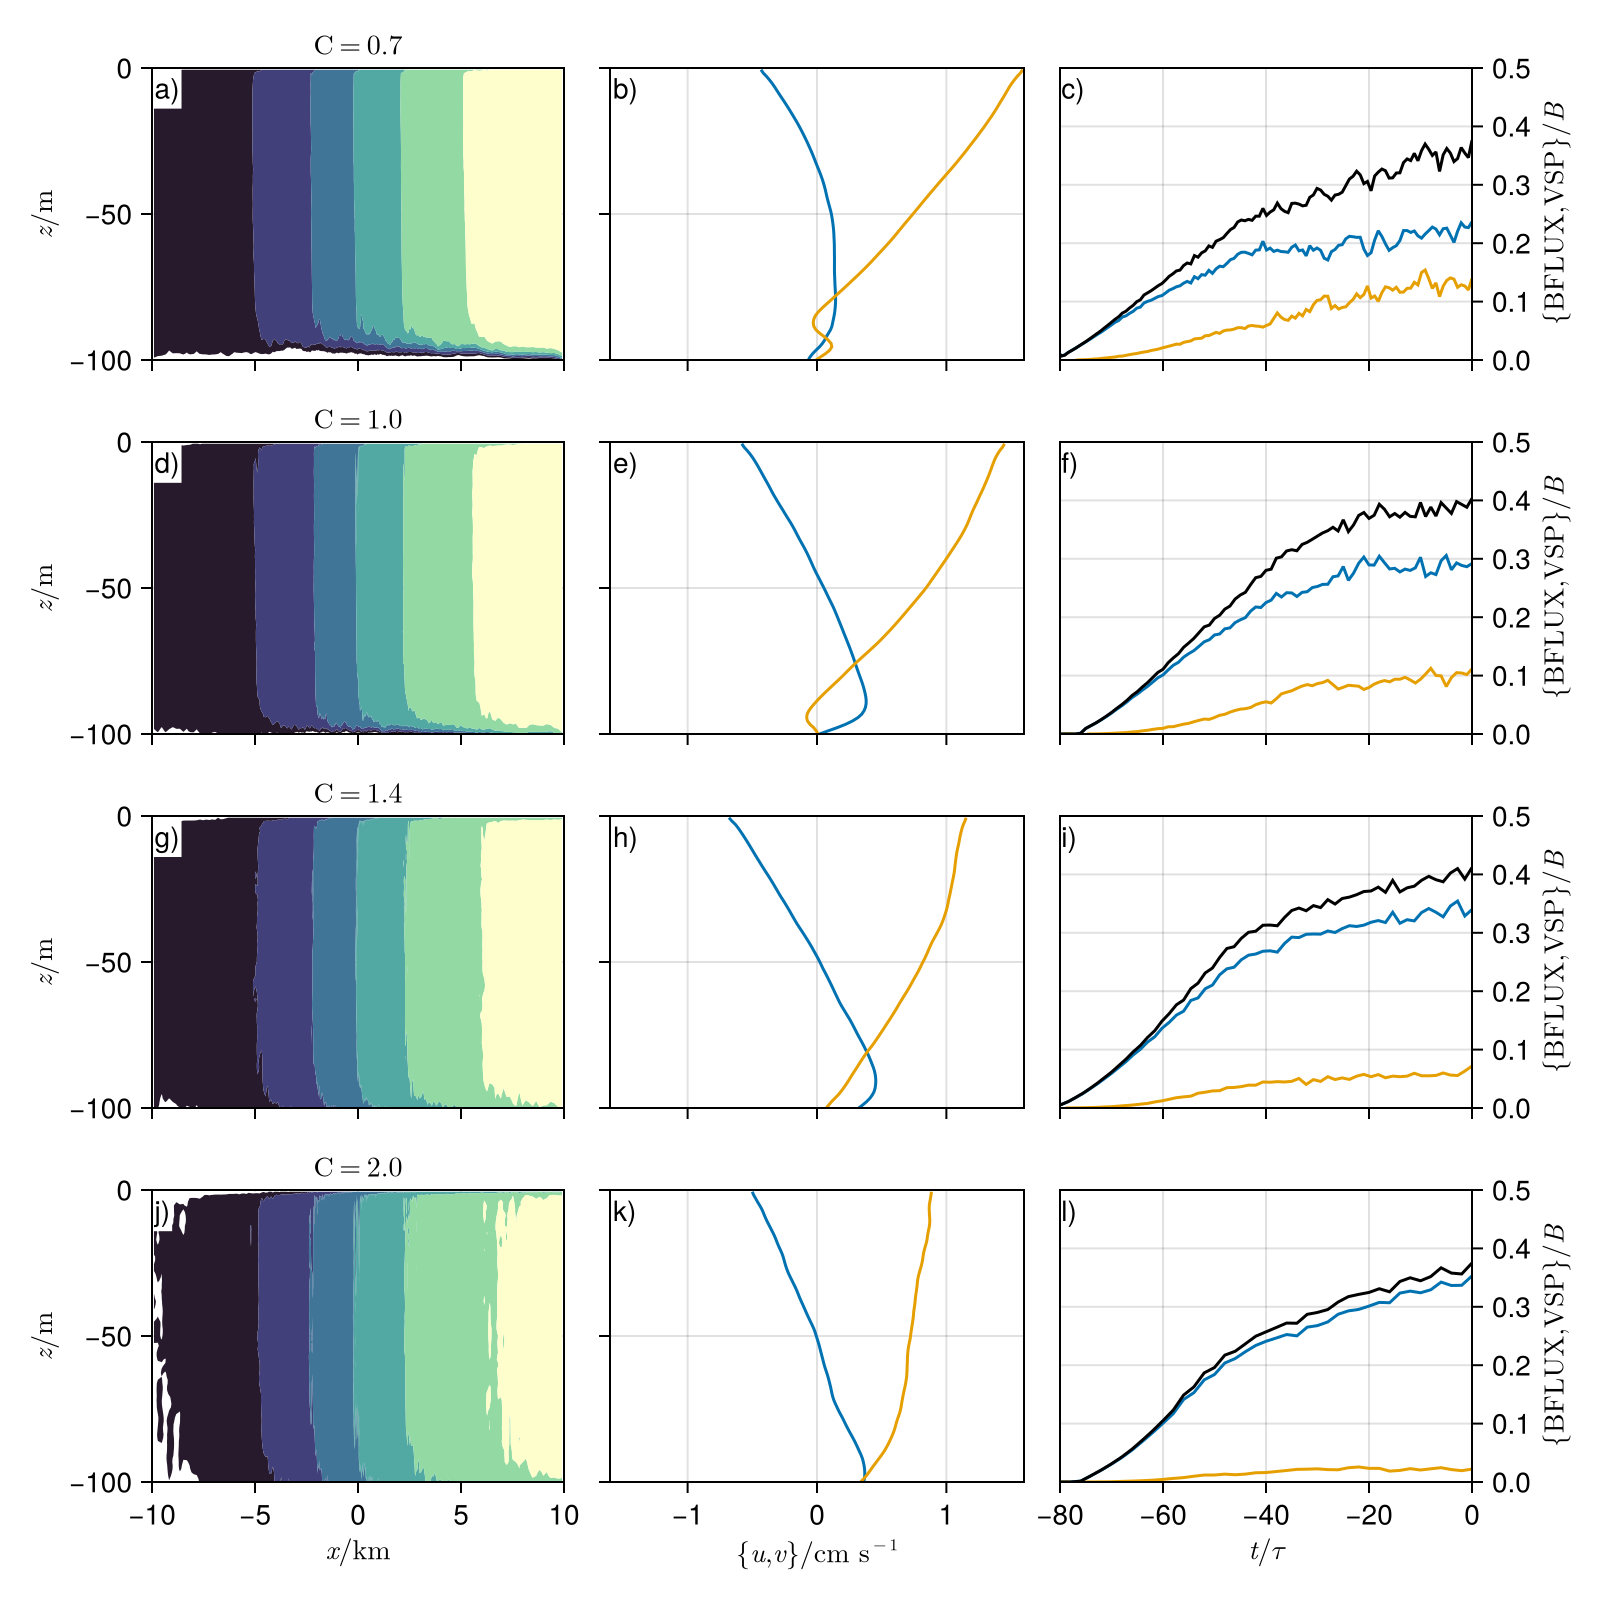

In [3]:
fig = Figure(; size=(800, 800))

for i in axes(foldernames, 1)
    DFM = joinpath(foldernames[i], "DFM.jld2")
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    inds = center_indices(DFM)
    
    
    C = @sprintf "%02.1f" sp.Ek
    ax = Axis(fig[i, 1];
        title = L"\text{C} = %$C",
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lx / 2000, sp.Lx / 2000, -sp.H, 0)
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false)
    
    levels = (-0.5):(1 / 6):(0.5)
    colormap = reverse(to_colormap(:deep))

    ctf = contourf!(ax, xsᶜ ./ 1000, zsᶜ, (bs[i] .- mean(bs_center[i][end, :])) ./ sp.Δb; 
        colormap,
        levels,
        extendlow=:white
    )

    ax = Axis(fig[i, 2];
        xlabel = L"\{u, v\} / \text{cm}~\text{s}^{-1}",
        ylabel = L"z / \text{m}",
        limits = (-1.6, 1.6, -sp.H, 0)
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false, grid=false)
    hideydecorations!(ax; ticks=false, grid=false)
    U = 0.01 #sp.L * sp.f
    lines!(ax, us[i] ./ U, zsᶜ)
    lines!(ax, vs[i] ./ U, zsᶜ)
    
    ax = Axis(fig[i, 3];
        xlabel = L"t/\tau",
        ylabel = L"\{\text{BFLUX}, \text{VSP}\} / B",
        limits = (-80, 0, 0, 0.5),
        yaxisposition = :right
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false, grid=false)
    
    BFLUX = sp.Lz / sp.H * BFLUXs[i] ./ sp.B
    VSP = sp.Lz / sp.H * VSPs[i] ./ sp.B
    
    lines!(ax, times ./ sp.τ, BFLUX)
    lines!(ax, times ./ sp.τ, VSP)
    lines!(ax, times ./ sp.τ, BFLUX .+ VSP; color=:black)

    subfig_label!(fig[i, 1], 3*(i-1) + 1)
    subfig_label!(fig[i, 2], 3*(i-1) + 2)
    subfig_label!(fig[i, 3], 3*(i-1) + 3)
end
#save("initialized-fronts.png", fig; px_per_unit=2)
#save("initialized-fronts.svg", fig)
fig

In [4]:
avgqs = map(foldernames) do foldername
    PV = joinpath(foldername, "PV.jld2")
    iterations, times = iterations_times(PV)
    inds = center_indices(PV)
    sp = simulation_parameters(PV)
    
    k1, k2 = zᶜbounds(PV, -0.8sp.H, -0.2sp.H)
    @inline center_avg(field) = mean(field[inds, k1:k2])
    timeseries_of(center_avg, PV, "q_dfm", iterations)
end

qs = map(foldernames) do foldername
    PV = joinpath(foldername, "PV.jld2")
    iterations, times = iterations_times(PV)
    
    
    filt(get_field(PV, "q_dfm", iterations[end]), 4, 1)
end;

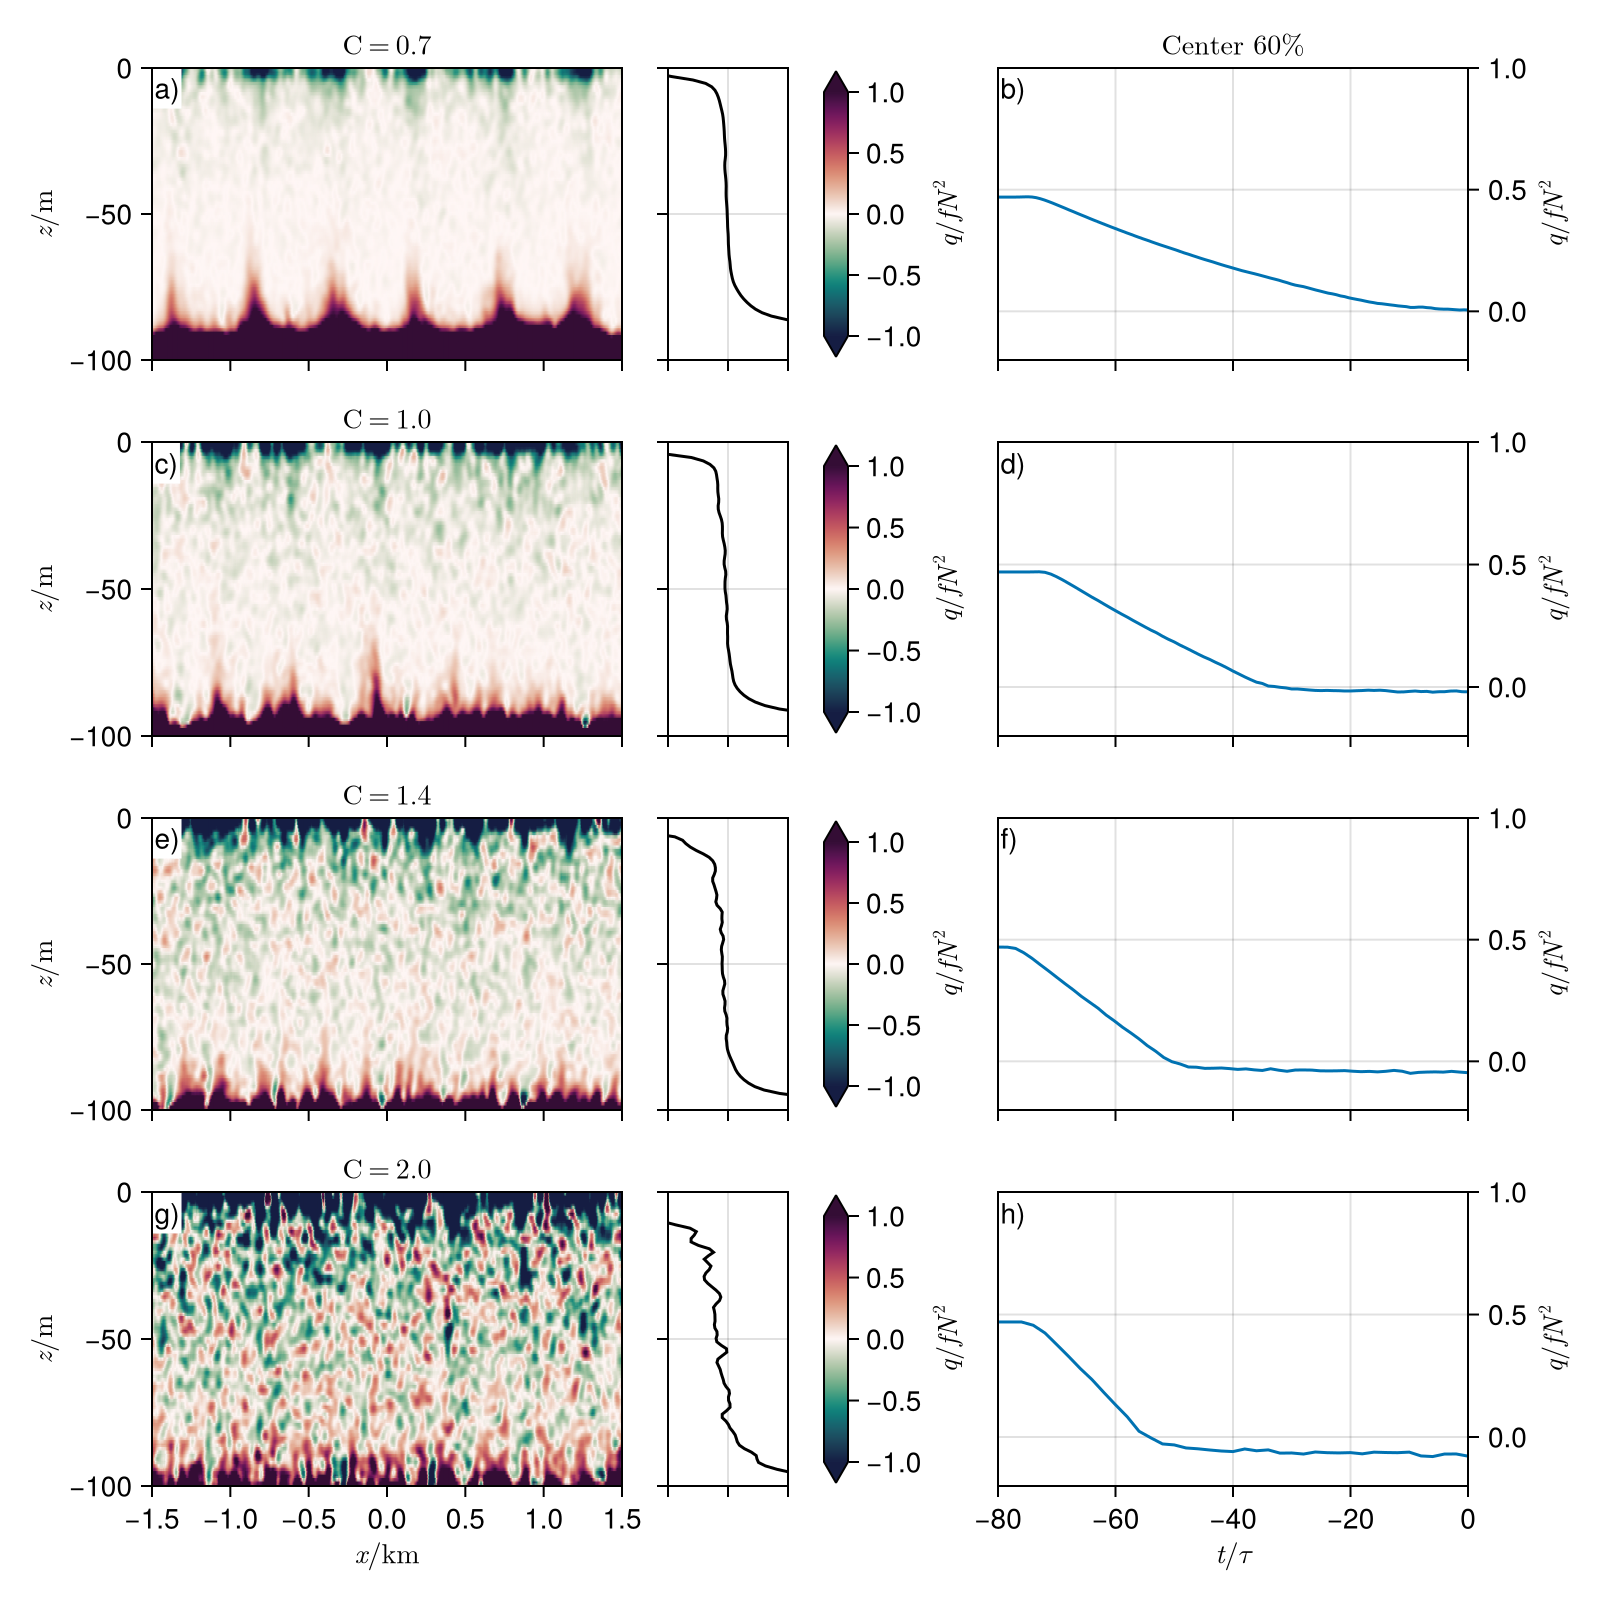

In [5]:
fig = Figure(; size=(800, 800))

for i in axes(foldernames, 1)
    DFM = joinpath(foldernames[i], "DFM.jld2")
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    inds = center_indices(DFM)
    
    C = @sprintf "%02.1f" sp.Ek
    ax = Axis(fig[i, 1];
        title = L"\text{C} = %$C",
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lh / 2000, sp.Lh / 2000, -sp.H, 0)
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false)

    q = qs[i] ./ (sp.f * sp.Δb / sp.H)
    colorrange = (-1, 1)
    colormap = to_colormap(:curl)

    ht = heatmap!(ax, xsᶜ ./ 1000, zsᶜ, q; 
        colormap,
        colorrange,
        highclip = colormap[end],
        lowclip = colormap[1],
    )
    
    Colorbar(fig[i, 3], ht; label=L"q / f N^2")
    
    ax = Axis(fig[i, 2];
        ylabel = L"z / \text{m}",
        xlabel = L"q / f N^2",
        limits = (-0.5, 0.5, -sp.H, 0),
        width = 60
    )
    hidexdecorations!(ax; ticks=false, grid=false)
    hideydecorations!(ax; ticks=false, grid=false)
    
    q_depth = mean(q[inds, :]; dims=1)[1, :]
    
    lines!(ax, q_depth, zsᶜ; color=:black)

    ax = Axis(fig[i, 4];
        xlabel = L"t/\tau",
        ylabel = L"q / f N^2",
        limits = (-80, 0, -0.2, 1),
        title = i == 1 ? L"\text{Center 60\%}" : "",
        yaxisposition = :right
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false, grid=false)
    
    avgq = avgqs[i] ./ (sp.f * sp.Δb / sp.H)
    
    lines!(ax, times ./ sp.τ, avgq)

    subfig_label!(fig[i, 1], 2*(i-1) + 1)
    subfig_label!(fig[i, 4], 2*(i-1) + 2)
end
save("initialized-pv.png", fig; px_per_unit=2)
save("initialized-pv.svg", fig)
fig